<a href="https://colab.research.google.com/github/jiyotirmaansingh/Heart-Risk-Predictor-using-ML/blob/main/Heart_Disease_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import pandas as pd

data = pd.read_csv('heart.csv')
data.head() # displays top 5 rows of the dataset.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [126]:
data.isnull().sum() # checks missing value in the dataset.

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [127]:
data_dup = data.duplicated().any() #takes care of duplicate values.
data_dup
#the output is true, that means there's duplicate data.

np.True_

In [128]:
#To remove duplicate data we perform the following code:

data = data.drop_duplicates()
data_dup = data.duplicated().any()
data_dup #the output is false, that means we have removed/dropped all the duplicates from the dataset.


np.False_

In [129]:
#Data Preprocessing:

cate_val = []
cont_val = []

for column in data.columns:
  if data[column].nunique() <= 10:
    cate_val.append(column) # if unique values are less that 10 then we can consider them in categorical column.
  else:
    cont_val.append(column) # else in contineous column.

In [130]:
cate_val # categorical columns.

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [131]:
cont_val # contineous columns.

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [132]:
# Encoding of categorical data:
data['cp'].unique()
# Converting the array into binary vector

array([0, 1, 2, 3])

In [133]:
# 1 0 0 0
# 0 1 0 0
# 0 0 1 0
# 0 0 0 1
cate_val.remove('sex')
cate_val.remove('target') # both of them contains 0 and 1 so we dont need them anymore.
data = pd.get_dummies(data,columns=cate_val,drop_first=True)
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [134]:
# Feature Scaling: ALlows us to put our features in the same scale.

from sklearn.preprocessing import StandardScaler

st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])
data.head()


,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [135]:
from sklearn.model_selection import train_test_split

# Splitting data into traning set and testing set:

X = data.drop('target', axis=1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train

,age,sex,trestbps,chol,thalach,oldpeak,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
163,-0.710788,1,-0.433587,0.532247,0.718568,-0.468334,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
291,0.396267,1,-0.205463,0.241930,-0.855851,1.687716,False,False,False,False,...,True,True,False,False,True,False,False,False,False,True
280,-1.042904,0,-0.091401,-0.241930,1.112172,-0.382092,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
85,-1.153610,1,-0.661712,-0.512893,0.893503,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
239,0.839089,0,1.049221,-0.048386,0.193761,0.307844,False,False,False,False,...,True,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,1.392616,1,-0.661712,-0.183867,-3.436149,-0.037124,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
77,0.949794,1,0.478910,-1.151589,-0.243577,2.550136,False,False,False,False,...,True,False,True,False,True,False,False,False,False,True
125,0.617678,0,1.049221,-0.125804,0.937237,-0.123366,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
522,1.392616,0,1.163283,0.590310,0.980971,-0.899544,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False


In [136]:
y_train

,target
163,0
291,0
280,1
85,1
239,0
...,...
267,0
77,0
125,1
522,1


In [137]:
X_test

,age,sex,trestbps,chol,thalach,oldpeak,cp_1,cp_2,cp_3,fbs_1,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
245,-1.153610,1,-0.091401,-0.532247,1.680713,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
349,0.839089,0,-0.091401,0.319348,-2.299069,0.135360,False,True,False,False,...,False,True,False,True,False,False,False,False,False,True
135,0.396267,0,2.189843,-0.416120,-0.156110,1.515232,False,False,False,True,...,True,True,False,False,True,False,False,True,False,False
389,0.949794,1,0.764066,-0.261285,0.018826,1.084022,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
66,-0.157260,1,-0.091401,-0.958045,0.106294,0.135360,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,1.724733,1,1.391408,-0.029032,-0.287311,-0.899544,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
123,1.171205,0,0.478910,3.299932,0.324963,-0.209608,False,True,False,True,...,False,False,True,True,False,False,False,False,True,False
739,-0.267966,1,-0.205463,0.164513,0.499898,-0.899544,False,False,False,False,...,True,False,True,True,False,False,False,False,False,True
274,1.281911,1,1.619532,-0.358057,-0.505981,1.084022,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [138]:
y_test

,target
245,1
349,0
135,0
389,1
66,1
...,...
402,1
123,1
739,0
274,1


In [139]:
# Logistic Regression:

from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [140]:
y_pred1 = log.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred1) # it is around 78% accurate on logical regression

0.7868852459016393

In [141]:
# SVC: Support Vector Classifier:

from sklearn import svm
svm = svm.SVC()
svm.fit(X_train,y_train)

SVC()

In [142]:
y_pred2 = svm.predict(X_test)
accuracy_score(y_test,y_pred2) # it is around 80% accurate on svc

0.8032786885245902

In [143]:
# K-Neighbors Classifier:

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)


KNeighborsClassifier()

In [144]:
y_pred3 = knn.predict(X_test)
accuracy_score(y_test,y_pred3) # it is around 73% accurate

0.7377049180327869

In [145]:
score = []

for k in range(1,40):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  score.append(accuracy_score(y_test,y_pred))


In [146]:
score # accuracy scores of different values of k

[0.7213114754098361,
 0.8032786885245902,
 0.7049180327868853,
 0.7049180327868853,
 0.7377049180327869,
 0.8032786885245902,
 0.7868852459016393,
 0.8032786885245902,
 0.7704918032786885,
 0.7540983606557377,
 0.7704918032786885,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7540983606557377,
 0.7704918032786885,
 0.7540983606557377,
 0.7540983606557377,
 0.7377049180327869,
 0.7540983606557377,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869]

In [147]:
knn = KNeighborsClassifier(n_neighbors=2) # for k = 2
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_score(y_test,y_pred) # now the accuracy has increase to 80%

0.8032786885245902

In [148]:
# Non-Linear Machine Learning Algos:
data = pd.read_csv('heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [149]:
data = data.drop_duplicates()
data.shape

(302, 14)

In [150]:
X= data.drop('target', axis=1)
y=data['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [151]:
# Decision Tree Classifier:

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)


DecisionTreeClassifier()

In [152]:
y_pred4 = dt.predict(X_test)
accuracy_score(y_test,y_pred4) # it has a accuracy of 77%

0.7377049180327869

In [153]:
# Random Forest Classifier:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred5 = rf.predict(X_test)
accuracy_score(y_test,y_pred5) # it has a accuracy of 85%


0.8524590163934426

In [154]:
# Gradient Boosting Classifier:

from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()
gbc.fit(X_train,y_train)
y_pred6 = gbc.predict(X_test)
accuracy_score(y_test,y_pred6) # it has a accuracy of 80%


0.8032786885245902

In [155]:
from sklearn.metrics import accuracy_score
import pandas as pd

final_data = pd.DataFrame({
    'Models': ['LR', 'SVM', 'KNN', 'DT', 'RF', 'GB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3),
        accuracy_score(y_test, y_pred4),
        accuracy_score(y_test, y_pred5),
        accuracy_score(y_test, y_pred6)
    ]
})

final_data

,Models,Accuracy
0,LR,0.786885
1,SVM,0.803279
2,KNN,0.737705
3,DT,0.737705
4,RF,0.852459
5,GB,0.803279


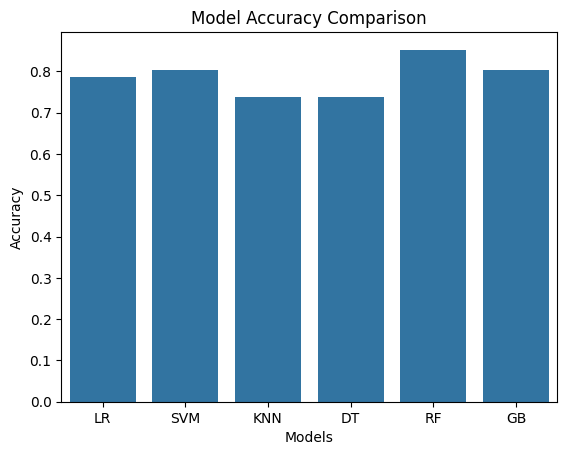

In [156]:
# Bar Plot:

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Models', y='Accuracy', data=final_data)
plt.title("Model Accuracy Comparison")
plt.show()

In [157]:
X = data.drop('target',axis=1)
y = data['target']

X.shape

(302, 13)

In [158]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X,y)


RandomForestClassifier()

In [159]:
# Prediction on new data:

new_data = pd.DataFrame({
    'age': 52,
    'sex': 1,
    'cp': 0,
    'trestbps': 125,
    'chol': 212,
    'fbs': 0,
    'restecg': 1,
    'thalach': 168,
    'exang': 0,
    'oldpeak': 1.0,
    'slope': 2,
    'ca': 2,
    'thal': 3
}, index=[0])

new_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3


In [160]:
p = rf.predict(new_data)
if p[0] == 0 :
  print("No Disease")
else:
  print("Disease")

No Disease


In [161]:
# Saving Model using Joblib:

import joblib

joblib.dump(rf, 'model_joblib_heart')
model = joblib.load('model_joblib_heart')
model.predict(new_data)

array([0])

In [162]:
# GUI

from IPython.display import HTML, display

display(HTML("""
<style>
/* center entire UI */
.widget-area {
    display:flex;
    justify-content:center;
}

/* main card */
.card {
    background:#ffffff;
    padding:30px 40px;
    border-radius:22px;
    box-shadow:0 20px 40px rgba(0,0,0,0.08);
    width:360px;
    font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
}

/* title */
.title {
    font-size:22px;
    font-weight:600;
    text-align:center;
    margin-bottom:20px;
}

/* labels */
.widget-label {
    font-size:13px !important;
    color:#666 !important;
}

/* inputs */
input, select {
    border-radius:12px !important;
}

/* toggle buttons */
.widget-toggle-buttons button {
    border-radius:12px !important;
    padding:8px 18px !important;
    margin:4px !important;
    border:none !important;
    background:#f2f2f2 !important;
    color:#333 !important;
    font-weight:500 !important;
}

/* selected toggle */
.widget-toggle-buttons button.mod-active {
    background:black !important;
    color:white !important;
}

/* predict button */
.predict-btn button {
    background:black !important;
    color:white !important;
    border-radius:14px !important;
    padding:12px !important;
    font-weight:600 !important;
    letter-spacing:0.5px;
}

/* result text */
.result {
    text-align:center;
    margin-top:15px;
    font-size:18px;
    font-weight:600;
}
</style>
"""))

import ipywidgets as widgets

age = widgets.IntText(value=52, description="Age")
sex = widgets.ToggleButtons(options=[('Female',0),('Male',1)], description="Sex")
cp = widgets.Dropdown(options=[0,1,2,3], description="Chest Pain")
trestbps = widgets.IntText(value=120, description="BP")
chol = widgets.IntText(value=200, description="Cholesterol")
fbs = widgets.ToggleButtons(options=[('No',0),('Yes',1)], description="Sugar")
restecg = widgets.Dropdown(options=[0,1,2], description="ECG")
thalach = widgets.IntText(value=150, description="Max HR")
exang = widgets.ToggleButtons(options=[('No',0),('Yes',1)], description="Angina")
oldpeak = widgets.FloatText(value=1.0, description="Oldpeak")
slope = widgets.Dropdown(options=[0,1,2], description="Slope")
ca = widgets.Dropdown(options=[0,1,2,3], description="Vessels")
thal = widgets.Dropdown(options=[1,2,3], description="Thal")

button = widgets.Button(description="Predict")
button.add_class("predict-btn")
output = widgets.HTML()

def predict_disease(b):
    new_data = pd.DataFrame({
        'age': age.value,
        'sex': sex.value,
        'cp': cp.value,
        'trestbps': trestbps.value,
        'chol': chol.value,
        'fbs': fbs.value,
        'restecg': restecg.value,
        'thalach': thalach.value,
        'exang': exang.value,
        'oldpeak': oldpeak.value,
        'slope': slope.value,
        'ca': ca.value,
        'thal': thal.value
    }, index=[0])

    pred = model.predict(new_data)[0]

    if pred == 0:
        output.value = "<div class='result' style='color:#16a34a;'>✓ No Heart Disease Risk</div>"
    else:
        output.value = "<div class='result' style='color:#dc2626;'>⚠ Heart Disease Risk</div>"

button.on_click(predict_disease)

form = widgets.VBox([
    widgets.HTML("<div class='title'>Heart Risk Predictor</div>"),
    age, sex, cp, trestbps, chol,
    fbs, restecg, thalach,
    exang, oldpeak, slope, ca, thal,
    button, output
])

display(HTML("<div class='widget-area'><div class='card'></div></div>"))
display(form)
